✅ Bắt đầu EDA & Visualization...

Kích thước dữ liệu sau cleaning: (283, 11)

Các cột: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'car_age', 'km_per_year']

1. THỐNG KÊ MÔ TẢ


,Year,Selling_Price,Present_Price,Kms_Driven,Owner,car_age,km_per_year
count,283.00,283.00,283.00,283.00,283.00,283.00,283.00
mean,2013.54,3.70,6.17,36415.91,0.05,12.46,2732.41
std,2.92,3.05,5.11,38996.55,0.26,2.92,2251.96
min,2003.00,0.10,0.32,500.00,0.00,8.00,50.00
25%,2012.00,0.75,1.02,15000.50,0.00,10.00,1375.00
50%,2014.00,3.25,5.87,32000.00,0.00,12.00,2522.80
75%,2016.00,5.50,9.40,48383.50,0.00,14.00,3656.44
max,2018.00,12.90,23.73,500000.00,3.00,23.00,27777.78



Giá xe trung bình: 3.7
Giá xe median: 3.25
Giá xe cao nhất: 12.9

2. PHÂN TÍCH BIẾN PHÂN LOẠI

Fuel_Type:
Fuel_Type
Petrol    236
Diesel     45
CNG         2
Name: count, dtype: int64
----------------------------------------

Seller_Type:
Seller_Type
Dealer        178
Individual    105
Name: count, dtype: int64
----------------------------------------

Transmission:
Transmission
Manual       256
Automatic     27
Name: count, dtype: int64
----------------------------------------

Owner:
Owner
0    272
1     10
3      1
Name: count, dtype: int64
----------------------------------------

3. TRỰC QUAN HÓA DỮ LIỆU


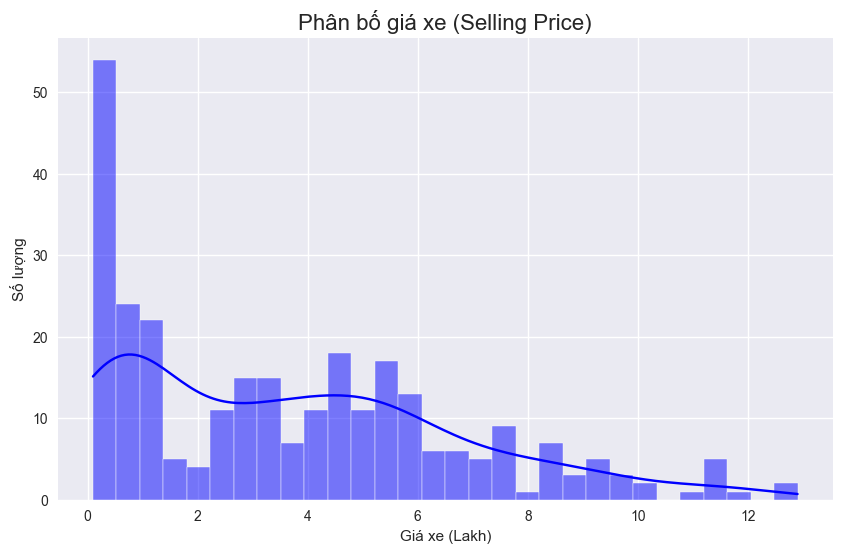

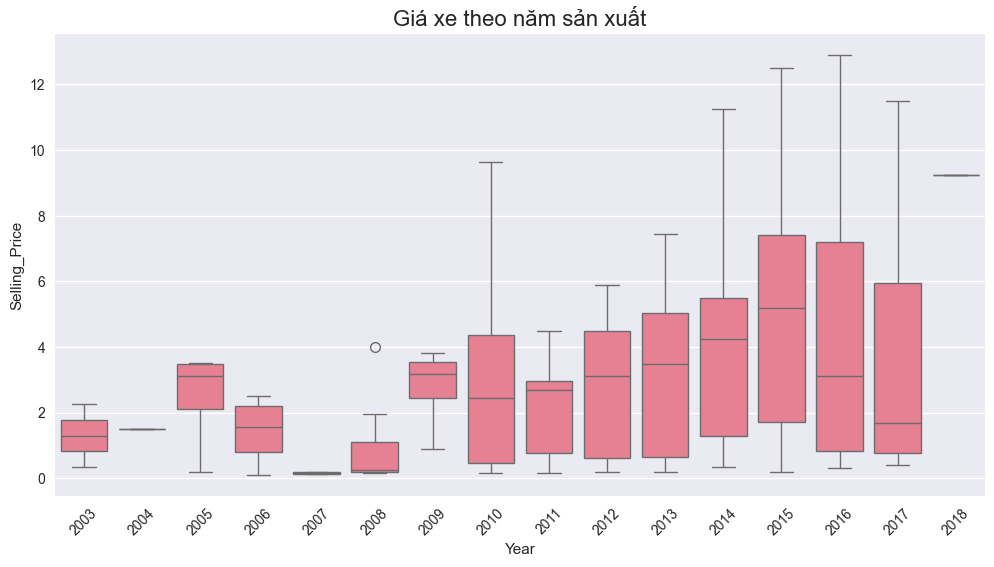

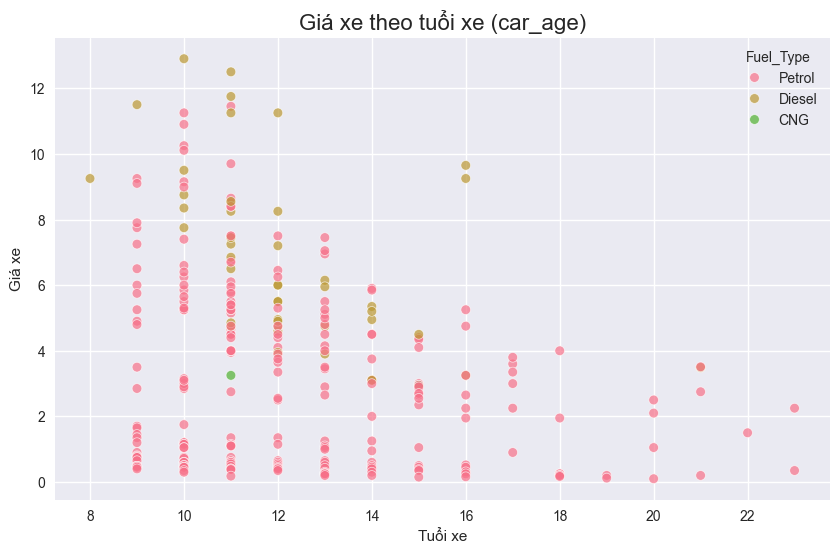

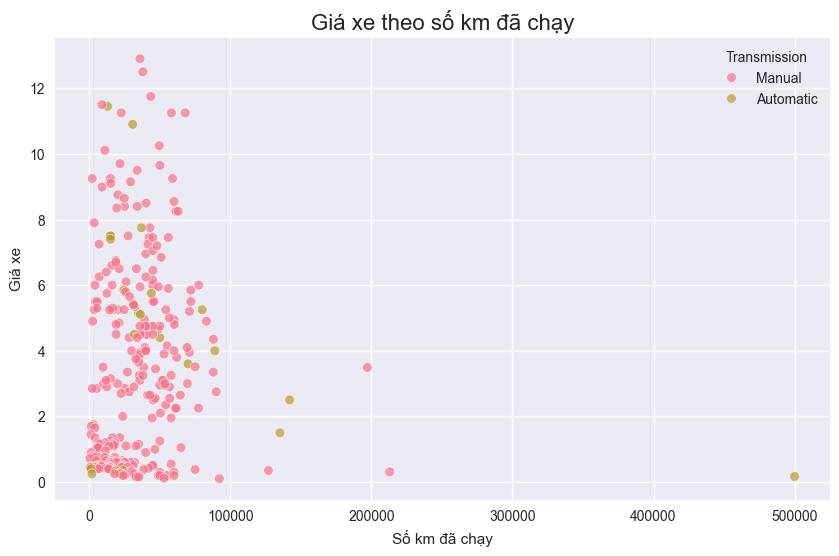

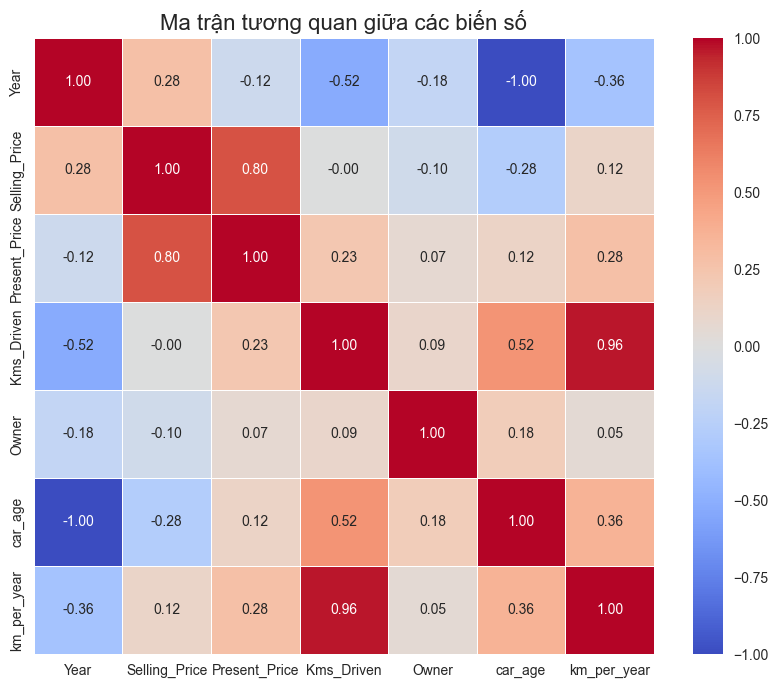

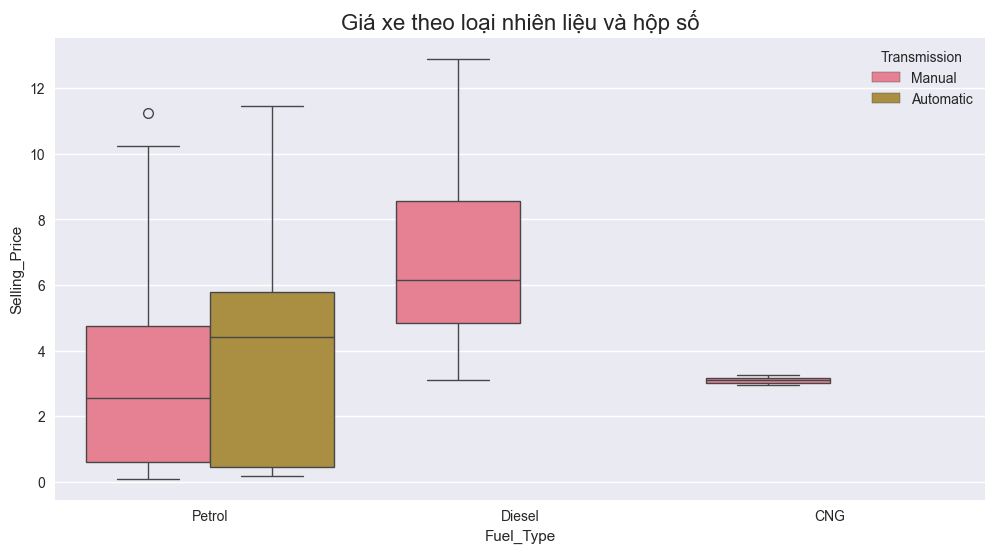


✅ Hoàn thành EDA & Visualization!
Các biểu đồ đã được lưu trong thư mục: reports/figures/
Bạn có thể mở thư mục reports/figures để xem tất cả hình ảnh.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Thiết lập style đẹp cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Bắt đầu EDA & Visualization...\n")

# Đọc dữ liệu đã clean
df = pd.read_csv('data/processed/car_data_cleaned.csv')

print("Kích thước dữ liệu sau cleaning:", df.shape)
print("\nCác cột:", df.columns.tolist())

# ====================== 1. THỐNG KÊ MÔ TẢ ======================
print("\n" + "="*80)
print("1. THỐNG KÊ MÔ TẢ")
print("="*80)
display(df.describe().round(2))

print("\nGiá xe trung bình:", round(df['Selling_Price'].mean(), 2))
print("Giá xe median:", round(df['Selling_Price'].median(), 2))
print("Giá xe cao nhất:", round(df['Selling_Price'].max(), 2))

# ====================== 2. PHÂN TÍCH BIẾN PHÂN LOẠI ======================
print("\n" + "="*80)
print("2. PHÂN TÍCH BIẾN PHÂN LOẠI")
print("="*80)

cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)

# ====================== 3. VISUALIZATION ======================
print("\n" + "="*80)
print("3. TRỰC QUAN HÓA DỮ LIỆU")
print("="*80)

# Tạo thư mục lưu hình
os.makedirs('reports/figures', exist_ok=True)

# 3.1 Histogram phân bố giá xe
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], kde=True, bins=30, color='blue')
plt.title('Phân bố giá xe (Selling Price)', fontsize=16)
plt.xlabel('Giá xe (Lakh)')
plt.ylabel('Số lượng')
plt.savefig('reports/figures/01_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.2 Boxplot giá theo năm sản xuất
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Selling_Price', data=df)
plt.title('Giá xe theo năm sản xuất', fontsize=16)
plt.xticks(rotation=45)
plt.savefig('reports/figures/02_price_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.3 Scatter plot: Giá ~ Tuổi xe
plt.figure(figsize=(10, 6))
sns.scatterplot(x='car_age', y='Selling_Price', data=df, hue='Fuel_Type', alpha=0.7)
plt.title('Giá xe theo tuổi xe (car_age)', fontsize=16)
plt.xlabel('Tuổi xe')
plt.ylabel('Giá xe')
plt.savefig('reports/figures/03_price_vs_age.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.4 Scatter plot: Giá ~ Số km đã chạy
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df, hue='Transmission', alpha=0.7)
plt.title('Giá xe theo số km đã chạy', fontsize=16)
plt.xlabel('Số km đã chạy')
plt.ylabel('Giá xe')
plt.savefig('reports/figures/04_price_vs_kms.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.5 Heatmap tương quan
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số', fontsize=16)
plt.savefig('reports/figures/05_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.6 Boxplot giá theo loại nhiên liệu và hộp số
plt.figure(figsize=(12, 6))
sns.boxplot(x='Fuel_Type', y='Selling_Price', hue='Transmission', data=df)
plt.title('Giá xe theo loại nhiên liệu và hộp số', fontsize=16)
plt.savefig('reports/figures/06_price_by_fuel_transmission.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Hoàn thành EDA & Visualization!")
print("Các biểu đồ đã được lưu trong thư mục: reports/figures/")
print("Bạn có thể mở thư mục reports/figures để xem tất cả hình ảnh.")